## 77K Fet Testing

This notebook contains all relevant information for the 77K test of one of the FET devices fabricated by Tanmay. This test was done to ensure that:

1. Slow and fast 2D sweeps are obtainable using the Qblox SPI Rack and Cluster, in combination with the MFLI Lock-In Amplifier. 

2. The bias tees assembled in-house are effective up to frequencies of ~100 kHz (that being the limit of the IV Preamp).

3. Data can be acquired both using the MFLI for slow 2D sweeps, and using the QRM for fast 2D sweeps.

This notebook also serves to ensure that the 1D and 2D methods of the Qblox Experiment class are sufficiently robust for use in the lab (more details provided below).


Authors: Ben Van Osch, Zeyu Lu

Created: 08/06/2025
Last Updated: 08/06/2025

### Experimental Setup

Break Out Box connection:

- 3: Source has 1/100 divider
- 6: Drain
- 15: Coarse Gate
- 18: Fine Gate

MFLI Setup:

- Reference Frequency: 70kHz
- Output Amplitudes: 500mV
- Low-Pass Filter time constant: 0.00692291s
- Low-Pass Filter Order: 4
- Signal input Scaling 1.4V/V
- AUX 4 is Demod R and scale is 1
- input voltage scaling: 1.4


SPI rack spec:

- DAC2(number on spi rack hardware) (dac1 in code)---> fine gate
- DAC3(number on spi rack hardware) (dac2 in code)---> coarse gate

Qblox Cluster spec:

QCM:

- O1 ---> fine gate
- O2 ---> coarse gate

QRM:

- MFLI AUX 4 ----> I1 

Pre-AMP

- Turn it on 
- 10^-6 A/V
- Rise time: MIN
- drain ---> input
- output ---> MFLI voltage input

### Code 

In [1]:
# Imports
import time
import matplotlib.pyplot as plt
import pyvisa
import numpy as np
from __future__ import annotations 
from typing import TYPE_CHECKING, Callable
from qcodes.instrument import find_or_create_instrument
from qblox_instruments import Cluster, ClusterType
if TYPE_CHECKING:
    from qblox_instruments.qcodes_drivers.module import Module

import os 
from pathlib import Path
path = Path(os.getcwd())

# update base working directory to QBlox
if path.stem != 'QBlox-CSG':
    base_dir = path.parents[1]
    os.chdir(base_dir)
else:
    base_dir = path


import sys
sys.path.append(r"C:\Users\BaughLaflamme\Documents\GitHub\QBlox-CSG\Libraries\QbloxSequenceHelpers")
import sequence_helperV2 as sh
import benchmarking as bm

from qblox_instruments import SpiRack
import numpy as np
import time

from zhinst.toolkit import Session

D5A_ADDRESS_1 = 8 #First D5a module from the left
D5A_ADDRESS_2 = 7 #Second D5a moduel from the left

#### Create an instrance of QbloxExperiment()

In [2]:
new_experiment = bm.QbloxExperiment()

{2: <Module: cluster0_module2 of Cluster: cluster0>, 4: <Module: cluster0_module4 of Cluster: cluster0>, 6: <Module: cluster0_module6 of Cluster: cluster0>}
Status: BOOTING, Flags: NONE, Slot flags: NONE
Connected to: Qblox SPI Rack (serial:None, firmware:{'device': 'v1.6 - May 10 2019 - mt', 'driver': {'version': '0.15.0', 'build': '20/12/2024-16:46:05', 'hash': '5fc66717', 'dirty': False}}) in 0.01s
MFLI setup completed. The MFLI is currently off


#### Initial baseline current

Measure current (before turning on any instrument): 

$10^{-6} \ \mathrm{\frac{A}{V}} \times 300 \ \mathrm{\mu V} = 0.3 \ \mathrm{nA}$


Measure Current (After turning on MFLI):

$10^{-6} \ \mathrm{\frac{A}{V}} \times 30 \ \mathrm{mV} = 30 \ \mathrm{nA}$


##### Decrease output amplitudes on MFLI  to 100 mV

Measure Current now: $10^{-6} \ \mathrm{\frac{A}{V}} \times 5 \ \mathrm{mV} = 5 \ \mathrm{nA}$

Resistance of the FET: 1mV/5nA = 0.2 MΩ (megaohms)

##### Double the bias voltage on MFLI (200mV on output amplitudes)

$10^{-6} \ \mathrm{\frac{A}{V}} \times 11 \ \mathrm{mV} = 11 \ \mathrm{nA}$


#### DC sweep on coarse gate

In [1]:
new_experiment.spirack_1D_trace(num_steps = 1000,
							time_per_point = 0.02, 
							set_point = 2, #only dac2 from zero to 2.5
							start_point = 0, 
							end_point = 4.5, 
                            play_repeats = 1, 
                            save_path = r'C:\Users\BaughLaflamme\Desktop\T16 Thermal ALD SET Room Temperature Test With Lock-In',
							plot = True)

NameError: name 'new_experiment' is not defined

#### DC sweep on the fine gate

Setting initial voltage on DAC 2
V_inner_set 0.0
V_inner_set 0.0
V_inner_set 0.00201416015625
V_inner_set 0.00201416015625
V_inner_set 0.0059814453125
V_inner_set 0.00799560546875
V_inner_set 0.010009765625
V_inner_set 0.01202392578125
V_inner_set 0.01202392578125
V_inner_set 0.0159912109375
V_inner_set 0.01800537109375
V_inner_set 0.02001953125
V_inner_set 0.02203369140625
V_inner_set 0.02203369140625
V_inner_set 0.0260009765625
V_inner_set 0.02801513671875
V_inner_set 0.030029296875
V_inner_set 0.03204345703125
V_inner_set 0.03204345703125
V_inner_set 0.0360107421875
V_inner_set 0.03802490234375
V_inner_set 0.0400390625
V_inner_set 0.04205322265625
V_inner_set 0.04205322265625
V_inner_set 0.0460205078125
V_inner_set 0.04803466796875
V_inner_set 0.050048828125
V_inner_set 0.05206298828125
V_inner_set 0.05206298828125
V_inner_set 0.0560302734375
V_inner_set 0.05804443359375
V_inner_set 0.06005859375
V_inner_set 0.06207275390625
V_inner_set 0.06207275390625
V_inner_set 0.0660400390625
V

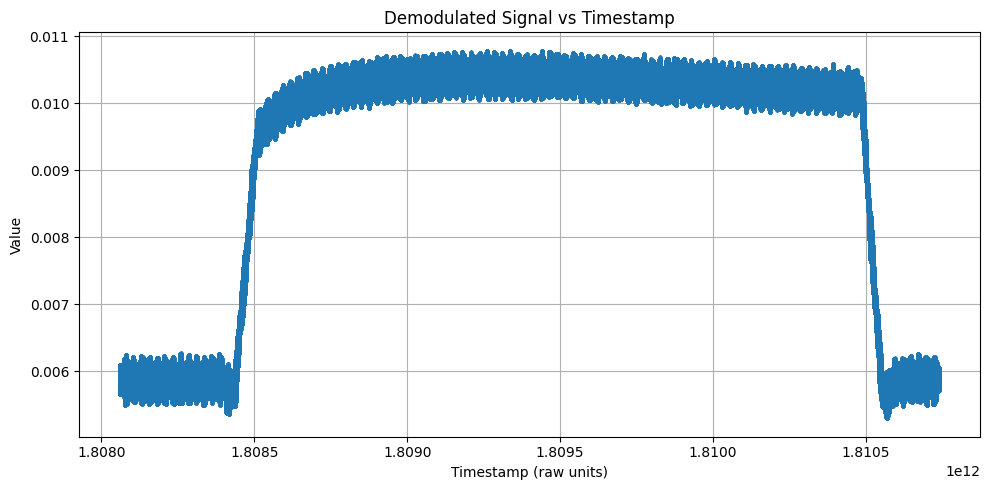

In [6]:
new_experiment.spirack_1D_trace_fine(num_steps = 1000,
							time_per_point = 0.02, 
							set_point = 3, #only dac2 from zero to 2.5
							start_point = 1, 
							end_point = 2, 
                            play_repeats = 1, 
                            save_path = r'C:\Users\BaughLaflamme\Desktop\T16 Thermal ALD SET Room Temperature Test With Lock-In',
							plot = True)

#### slow 2D sweep

MFLI setup completed. The MFLI is currently on
Setting initial voltage on DAC 1
Setting initial voltage on DAC 2
V_outter 0.0
V_inner_set 0.0
V_inner_set 0.0
V_inner_set 0.02020263671875
V_inner_set 0.0404052734375
V_inner_set 0.06060791015625
V_inner_set 0.080810546875
V_inner_set 0.10101318359375
V_inner_set 0.1212158203125
V_inner_set 0.14141845703125
V_inner_set 0.16162109375
V_inner_set 0.18182373046875
V_inner_set 0.2020263671875
V_inner_set 0.22222900390625
V_inner_set 0.242431640625
V_inner_set 0.26263427734375
V_inner_set 0.2828369140625
V_inner_set 0.30303955078125
V_inner_set 0.3232421875
V_inner_set 0.34344482421875
V_inner_set 0.3636474609375
V_inner_set 0.38385009765625
V_inner_set 0.404052734375
V_inner_set 0.42425537109375
V_inner_set 0.4444580078125
V_inner_set 0.46466064453125
V_inner_set 0.48486328125
V_inner_set 0.50506591796875
V_inner_set 0.5252685546875
V_inner_set 0.54547119140625
V_inner_set 0.565673828125
V_inner_set 0.58587646484375
V_inner_set 0.606079101562

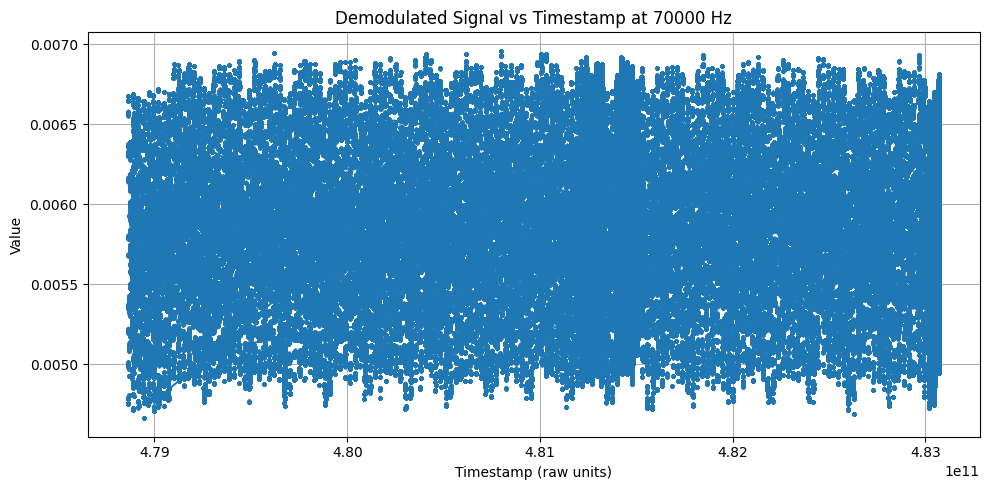

In [4]:
new_experiment.spirack_2D_sweep(num_steps = 100,
							time_per_point = 0.02, 
							start_points = [0, 0], #[, coarse]
							end_points = [4, 2], 
                            play_repeats = 1, 
                            save_path = r'C:\Users\BaughLaflamme\Desktop\T16 Thermal ALD SET Room Temperature Test With Lock-In',
							plot = True)

MFLI setup completed. The MFLI is currently on
['qblox fast sweep fast gate', 0, 10000000]


c:\Users\BaughLaflamme\anaconda3\envs\zh-test\lib\site-packages\qblox_instruments\native\spi_rack_modules\d5a_module.py:454: RuntimeWarning: invalid value encountered in double_scalars
  dt = np.abs(val_begin - val) / self._ramp_rate / num_steps


0.0006481029148347174
0.000753948868262498
໒(⊙ᴗ⊙)७✎▤: Plot has been saved at C:\Users\BaughLaflamme\Desktop\T16 Thermal ALD SET Room Temperature Test With Lock-In\1D_trace_NumSteps100_LengthPerPoint100000_fineGateVol2_coarseGateVol1_startPoint-1_endPoint1_resolution300 


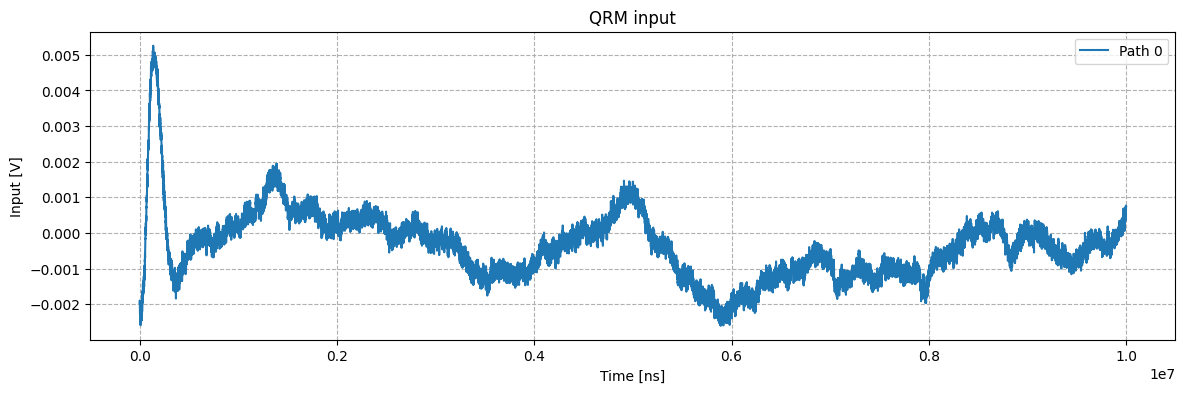

In [3]:
new_experiment.run_1D_trace(num_steps = 100,
							length_per_point = 100000,
							coarse_gate_voltage = 1,
							fine_gate_voltage = 2,
							start_point = -1,
							end_point = 1, 
                            acq_sequencer = 0,
							acquisition_name = "qblox fast sweep fast gate",
                            save_path = r'C:\Users\BaughLaflamme\Desktop\T16 Thermal ALD SET Room Temperature Test With Lock-In',
							plot = True)

MFLI setup completed. The MFLI is currently on
['qblox fast sweep fast gate', 0, 12500000]
0.02286435433968409
0.022922976713890247
໒(⊙ᴗ⊙)७✎▤: Plot has been saved at C:\Users\BaughLaflamme\Desktop\T16 Thermal ALD SET Room Temperature Test With Lock-In\1D_trace_NumSteps250_LengthPerPoint50000_fineGateVol4_coarseGateVol1_startPoint-0_5_endPoint0_5_resolution300 


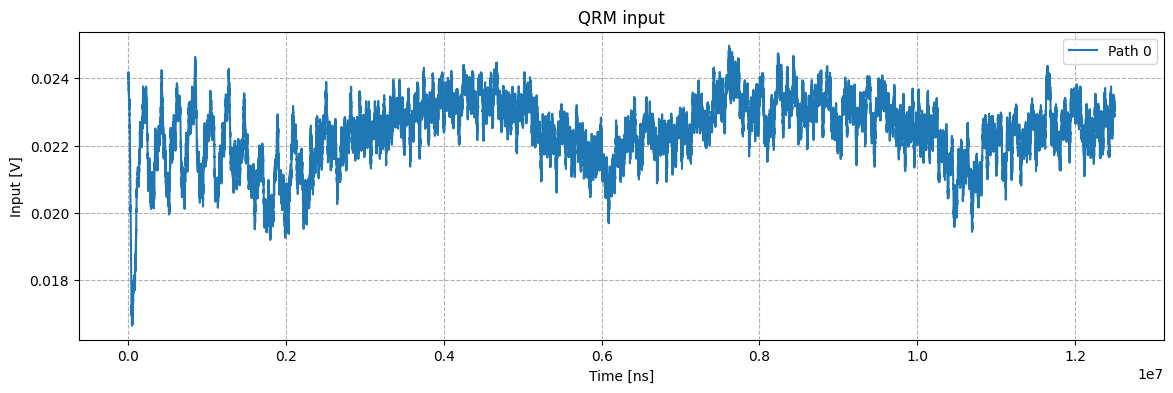

In [6]:
new_experiment.run_1D_trace_fine(num_steps = 250,
							length_per_point = 50000,
							coarse_gate_voltage = 1,
							fine_gate_voltage = 4,
							start_point = -0.5,
							end_point = 0.5, 
                            acq_sequencer = 0,
							acquisition_name = "qblox fast sweep fast gate",
                            save_path = r'C:\Users\BaughLaflamme\Desktop\T16 Thermal ALD SET Room Temperature Test With Lock-In',
							plot = True)

c:\Users\BaughLaflamme\anaconda3\envs\zh-test\lib\site-packages\qblox_instruments\native\spi_rack_modules\d5a_module.py:454: RuntimeWarning: invalid value encountered in double_scalars
  dt = np.abs(val_begin - val) / self._ramp_rate / num_steps


0.09481910112359551
0.09273590620420127
໒(⊙ᴗ⊙)७✎▤: Plot has been saved at C:\Users\BaughLaflamme\Desktop\\Lu and Rishabh\2D_sweep_NumSteps100_OuterSweepLength1000000_fineGateVol2_coarseGateVol1_startPoint[0, -1]_endPoint[0, 1]_resolution10000.png 


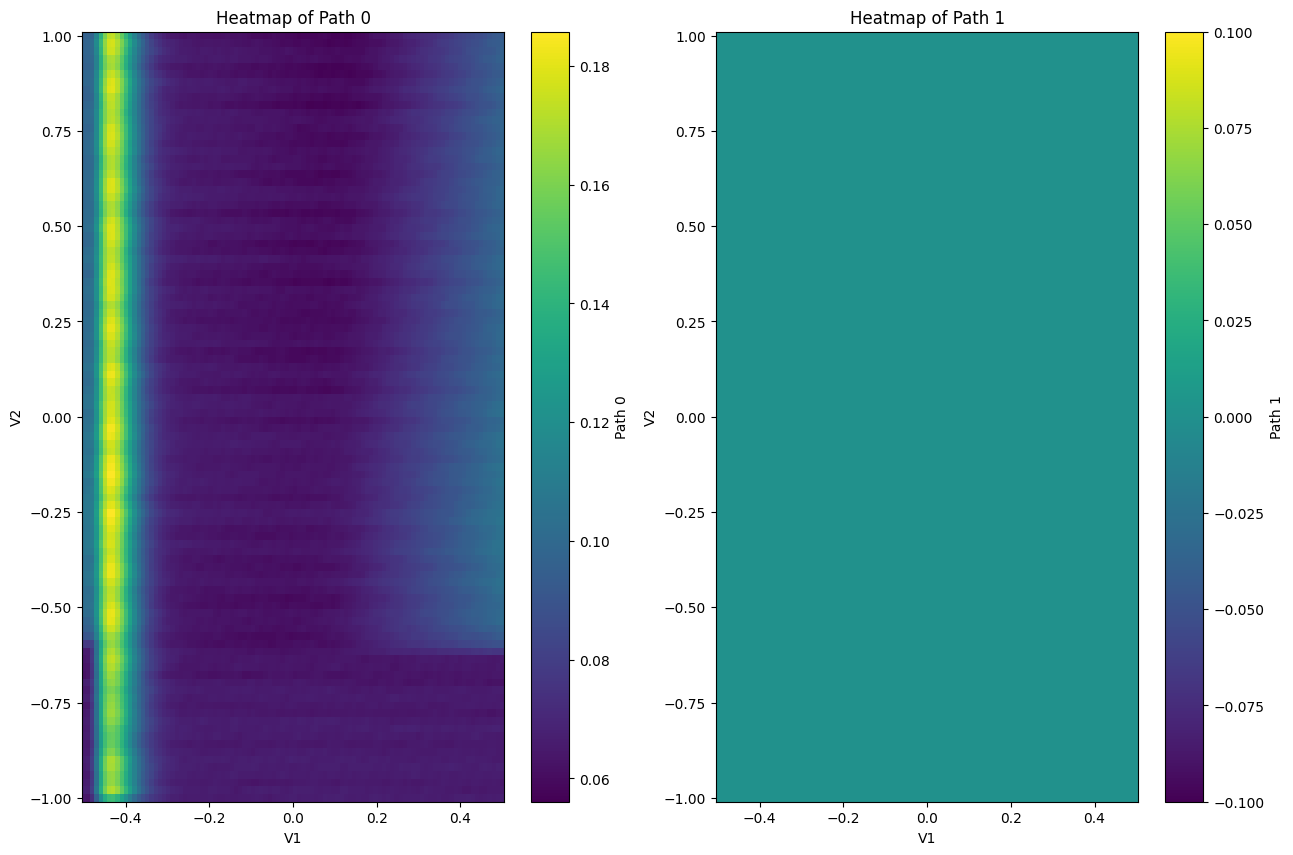

Status: OKAY, State: STOPPED, Info Flags: FORCED_STOP, Warning Flags: NONE, Error Flags: NONE, Log: []
False
False


In [4]:
new_experiment.run_2D_sweep(num_steps = 100,
						outer_sweep_length = int(10000)*100, 
						fine_gate_voltage = 2,
						coarse_gate_voltage = 1,
						start_points = [-0.5, -1], # fine gate, coarse gate
						end_points = [0.5, 1], 
						acq_sequencer = 0,
						acquisition_name = f"bias_tee_time_{int(time.time())}",
						resolution = int(10000),
						play_repeats = 1, 
						save_path = r'C:\Users\BaughLaflamme\Desktop\\Lu and Rishabh',
						plot = True)